In [1]:
import os
import spacy
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd
import numpy as np

# Load spaCy and VADER
nlp = spacy.load("en_core_web_sm")
analyzer = SentimentIntensityAnalyzer()

# Robust path resolution targeting project root data folder
POSSIBLE_PATHS = [
    os.path.abspath(os.path.join("..", "data", "processed", "processed_data.csv")),
    os.path.abspath(os.path.join("data", "processed", "processed_data.csv")),
    os.path.abspath(os.path.join(os.getcwd(), "data", "processed", "processed_data.csv")),
    os.path.abspath(os.path.join(os.getcwd(), "..", "data", "processed", "processed_data.csv"))
]

PROCESSED_PATH = None
for path in POSSIBLE_PATHS:
    if os.path.exists(path):
        PROCESSED_PATH = path
        break

if not PROCESSED_PATH:
    raise FileNotFoundError("processed_data.csv was not found. Please verify it exists inside data/processed/.")

df = pd.read_csv(PROCESSED_PATH)
print(f"Successfully loaded processed dataset from: {PROCESSED_PATH}")
print(f"Dataset shape: {df.shape}")
df.head()

Successfully loaded processed dataset from: D:\SIG Project\smartphone-absa-project\data\processed\processed_data.csv
Dataset shape: (57828, 11)


,asin,name,rating,date,verified,title,body,helpfulvotes,brand,clean_review,review_length
0,B0000SX2UC,Janet,3,"October 11, 2005",False,"Def not best, but not worst",I had the Samsung A600 for awhile which is abs...,1.0,DEF,I had the Samsung A600 for awhile which is abs...,327
1,B0000SX2UC,Luke Wyatt,1,"January 7, 2004",False,Text Messaging Doesn't Work,Due to a software issue between Nokia and Spri...,17.0,TEXT,Due to a software issue between Nokia and Spri...,129
2,B0000SX2UC,Brooke,5,"December 30, 2003",False,Love This Phone,"This is a great, reliable phone. I also purcha...",5.0,LOVE,"This is a great, reliable phone. I also purcha...",131
3,B0000SX2UC,amy m. teague,3,"March 18, 2004",False,"Love the Phone, BUT...!","I love the phone and all, because I really did...",1.0,LOVE,"I love the phone and all, because I really did...",107
4,B0000SX2UC,tristazbimmer,4,"August 28, 2005",False,"Great phone service and options, lousy case!",The phone has been great for every purpose it ...,1.0,GREAT,The phone has been great for every purpose it ...,128


In [2]:
# Predefined whitelist of core smartphone aspects to focus extraction
VALID_ASPECTS = {
    "camera",
    "battery",
    "screen",
    "display",
    "processor",
    "performance",
    "battery life",
    "sound",
    "speaker",
    "price",
    "value",
    "design",
    "quality",
    "build",
    "memory",
    "storage",
}


def extract_aspect_opinion_pairs(text):
    doc = nlp(str(text))
    pairs = []

    for token in doc:
        aspect = None
        opinion = None

        # Rule 1: Adjective modifying a noun directly (e.g., "great camera")
        if token.pos_ == "ADJ" and token.head.pos_ in ["NOUN", "PROPN"]:
            noun_candidate = token.head.text.lower()
            if noun_candidate in VALID_ASPECTS:
                aspect = noun_candidate
                opinion = token.text.lower()

        # Rule 2: Noun subject linked to an adjective attribute (e.g., "battery is bad")
        elif token.pos_ in ["NOUN", "PROPN"] and token.text.lower() in VALID_ASPECTS:
            for child in token.children:
                if child.dep_ in ["amod", "acomp"] and child.pos_ == "ADJ":
                    aspect = token.text.lower()
                    opinion = child.text.lower()
                    break
            # Check syntactic head if attribute is predicate adjective
            if not aspect and token.head.pos_ == "ADJ" and token.dep_ in ["nsubj", "nsubjpass"]:
                aspect = token.text.lower()
                opinion = token.head.text.lower()

        if aspect and opinion:
            # Compute compound polarity score for the local opinion phrase using VADER
            vader_score = analyzer.polarity_scores(opinion)["compound"]
            pairs.append({"aspect": aspect, "opinion": opinion, "sentiment_score": vader_score})

    return pairs


# Test function sanity check on a sample review snippet
sample_text = "The camera quality is amazing, but the battery life is terrible and disappointing."
print("Sample Extraction Test:")
print(extract_aspect_opinion_pairs(sample_text))

Sample Extraction Test:
[]


In [3]:
# Optional: Take a representative sample for fast execution in notebook
df_sample = df.sample(n=min(3000, len(df)), random_state=42).reset_index(drop=True)

extracted_records = []

for idx, row in df_sample.iterrows():
    review_text = row["clean_review"]
    brand = row["brand"]
    rating = row.get("rating", row.get("score", np.nan))

    pairs = extract_aspect_opinion_pairs(review_text)

    for p in pairs:
        extracted_records.append(
            {
                "brand": brand,
                "rating": rating,
                "aspect": p["aspect"],
                "opinion": p["opinion"],
                "sentiment_score": p["sentiment_score"],
            }
        )

df_absa = pd.DataFrame(extracted_records)
print(f"Extracted ABSA records shape: {df_absa.shape}")
df_absa.head(10)

Extracted ABSA records shape: (1686, 5)


,brand,rating,aspect,opinion,sentiment_score
0,VERY,4,camera,decent,0.0000
1,VERY,4,camera,decent,0.0000
2,PHONE,1,screen,white,0.0000
3,PHONE,1,screen,white,0.0000
4,TAKES,5,quality,excellent,0.5719
5,TAKES,5,quality,excellent,0.5719
6,FIVE,5,display,good,0.4404
7,FIVE,5,display,good,0.4404
8,IPHONE,5,quality,great,0.6249
9,IPHONE,5,quality,great,0.6249


C:\Users\iworld\AppData\Local\Temp\ipykernel_26120\4008870591.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\iworld\AppData\Local\Temp\ipykernel_26120\4008870591.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


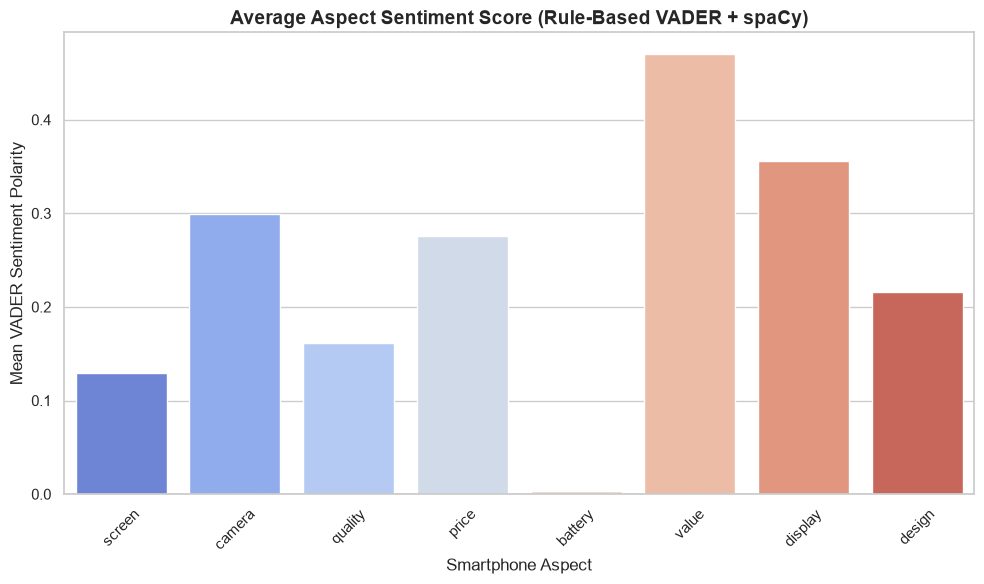

--- Aspect Summary Table ---
             mention_count  mean_sentiment
aspect                                    
screen                 321        0.129912
camera                 272        0.299270
quality                243        0.161841
price                  209        0.275985
battery                170        0.003325
value                   95        0.469678
display                 80        0.355836
design                  68        0.216416
storage                 55        0.034295
performance             51        0.318212


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Compute average sentiment score per aspect across top extracted features
top_aspects = df_absa["aspect"].value_counts().head(8).index
df_top_aspects = df_absa[df_absa["aspect"].isin(top_aspects)]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_top_aspects,
    x="aspect",
    y="sentiment_score",
    order=top_aspects,
    palette="coolwarm",
    ci=None,
)
plt.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.title("Average Aspect Sentiment Score (Rule-Based VADER + spaCy)", fontsize=14, fontweight="bold")
plt.xlabel("Smartphone Aspect", fontsize=12)
plt.ylabel("Mean VADER Sentiment Polarity", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print statistical summary per aspect
aspect_summary = (
    df_absa.groupby("aspect")
    .agg(mention_count=("sentiment_score", "count"), mean_sentiment=("sentiment_score", "mean"))
    .sort_values(by="mention_count", ascending=False)
)
print("--- Aspect Summary Table ---")
print(aspect_summary.head(10))

In [5]:
# Define output path for structured ABSA dataset
ABSA_OUTPUT_PATH = os.path.join("..", "data", "processed", "absa_structured_output.csv")
if not os.path.exists(os.path.dirname(ABSA_OUTPUT_PATH)):
    ABSA_OUTPUT_PATH = os.path.join("data", "processed", "absa_structured_output.csv")

# Ensure directory exists and save
os.makedirs(os.path.dirname(ABSA_OUTPUT_PATH), exist_ok=True)
df_absa.to_csv(ABSA_OUTPUT_PATH, index=False)
print(f"Successfully saved structured ABSA dataset to: {ABSA_OUTPUT_PATH}")

Successfully saved structured ABSA dataset to: ..\data\processed\absa_structured_output.csv
